# Метрики качества для задач классификации: точность и специфичность, F1, ROC AUC, PR AUC

Рассмотрим такие метрики, как точность (presicion), специфичность (specificity, true negative rate, TNR), F1-мера (F1-score), ROC AUC и PR AUC для бинарной и многоклассовой классификаций. Также рассмотрим долю правильных ответов (accuracy), которую часто путают с точностью. 



## Обозначения:   
* $\mathbf{y} = (y_1, ..., y_n)$ — правильные ответы
* В задаче бинарной классификации считаем, что $y_i \in \{0, 1\}$ для любого $i \in [1, n]$
* $\hat{\mathbf{y}} = (\hat{y}_1, ..., \hat{y}_n)$ — предсказания меток классов
* $\mathbf{p_i} = (p_1, ..., p_K)$ — предсказания вероятностей принадлежности к классам $\{ C_1, \ldots, C_K\}$ для любого $i \in [1, n]$
* В задаче бинарной классификации считаем, что 
$$p_1 = p \text{ – вероятность принадлежности к классу } 1$$
$$p_0 = 1 - p \text{ – вероятность принадлежности к классу } 0$$


## Точность, доля правильных ответов (accuracy)

Формула расчета **доли правильных ответов** выглядит одинаково и в случае бинарной, и в случае многоклассовой классификации (единственное, в многоклассовом случае ее можно считать как для всех классов в целом, так и для каждого класса по отдельности, а потом усреднить полученные значения): 

$$\text{accuracy} = \frac{1}{n} \sum_{i = 1}^{n}{1(\hat{y}_i == y_i)}, $$
где $1(x)$ — **индикаторная функция**. 



---
Пусть $A ⊆ X$ — выбранное подмножество произвольного множества $X$. Функция $1_A: X → \{0, 1\}$, определенная следующим образом: 

\begin{equation*}
1_A(x) = 
 \begin{cases}
   1, &\text{$x \in A$}\\
   0, &\text{$x \notin A$},
 \end{cases}
\end{equation*}  

называется **индикатором** множества $A$. 

---

$+$ Простая в понимании и интерпретации метрика.  
$-$ Неприменима, когда выборка несбалансированная (если в выборке будет очень мало объектов, представляющих какой-то класс, то даже константная модель (предсказания которой являются константой) покажет достаточно большую долю правильных ответов.

[Реализация в `sklearn`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)

## Точность (presicion) и специфичность (specificity/
true negative rate, TNR)


### Бинарная классификация

Перед тем как переходить к формулам непосредственно точности и специфичности, введем следующие обозначения, которые лучше всего записать в виде таблицы: 

|| $y = 0$ | $y = 1$ |
| :-----------: | :-----------: | :-----------: |
| $\hat{y} = 0$ | True negative (TN) | False negative (FN) |
| $\hat{y} = 1$ | False positive (FP) | True positive (TP) |

В данной таблице приняты следующие обозначения для объектов, попавших в каждую из ячеек:  
* TN — модель правильно классифицировала объект, и он принадлежит классу $0$
* FN — модель неправильно классифицировала объект, присвоила ему класс $0$, хотя он принадлежит классу $1$
* FP — модель неправильно классифицировала объект, присвоила ему класс $1$, хотя он принадлежит классу $0$
* TP — модель правильно классифицировала объект, и он принадлежит классу $1$

В терминах, введенных выше, **точность (precision)** и **специфичность (specificity/TNR)** выглядят следующим образом:

$$ \text{precision} = \frac{TP}{TP + FP} – \text{доля объектов, названных классификатором положительными и при этом действительно являющиеся положительными.}$$ 
$$ \text{TNR} = \frac{TN}{TN + FP}  
 – \text{показывает, какую долю объектов класса $0$ из всех объектов класса $0$ нашел алгоритм.}$$ 

Также весьма распространена метрика **полнота (recall)**, которая является «братом-близнецом» специфичности:
$$ \text{recall} = \frac{TP}{TP + FN}  
 – \text{показывает, какую долю объектов класса $1$ из всех объектов класса $1$ нашел алгоритм.}$$  

Визуализировать различие между точностью и полнотой можно следующим образом: 

![image.png](https://habrastorage.org/web/38e/9d4/892/38e9d4892d9241ea95e1f56e3ef9124c.png)  
[Рис. 1. Визуальное сравнение точности и полноты](https://en.wikipedia.org/wiki/Precision_and_recall)

**Точность (precision)** демонстрирует способность отличать класс $1$ от других классов, а **полнота (recall)** — способность алгоритма обнаруживать класс $1$ вообще (**специфичность** делает то же самое, что и полнота, только для класса $0$).

Аналогичным образом, через TN, FN, FP и TP, можно ввести и понятие **доли правильных ответов**: $\text{accuracy} = \frac{TP + TN}{TP + FP + TN + FN}.$



$+$ Как точность, так и специфичность и полнота не зависят, в отличие от доли правильных ответов, от соотношения классов, поэтому они применимы и для несбалансированных выборок.  
$-$ На практике обычно не стоит задача оптимизировать какую-то одну из этих метрик, а необходимо найти баланс между ними. 

### Многоклассовая классификация

Как и в случае доли правильных ответов, существуют два типа агрегации этих метрик в многоклассовом случае:  
* **Микро-** — необходимые значения вычисляются глобально, целиком по всей выборке, рассматривая каждый элемент матрицы показателей метки как метку  
* **Макро-** — метрика считается отдельно для каждого класса, и в качестве ответа берется их среднее значение



### Реализации (и для бинарного, и для многоклассового случая): 
* [Точность (precision)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)
* [Полнота (recall)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)  
* Специфичность (TRN). Реализации именно для специфичности нет, но можно получить из [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) все необходимые значения (TN, TP, FN, и FP)

## $F_1$-мера

Как упоминалось ранее, обычно важна не только точность или полнота, но и баланс между ними. Наиболее распространенной метрикой такого баланса является **$F_1$-мера** — среднее гармоническое точности и полноты:  
$$F_1 = \frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$  

**$F_1$-мера** достигает максимума при полноте и точности, равных единице, и близка к нулю, если один из аргументов близок к нулю.  


Как в случае точности, специфичности и полноты, формула верна и для бинарной, и для многоклассовой классификации, однако в многоклассовом случае необходимо уточнить вид агрегации: микро- (когда показатели считаются глобально для всей выборки) или макро- (точность и полнота считаются отдельно для каждого класса, а в качестве ответа берется среднее).   
[Реализация в `sklearn`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)

Существуют и другие варианты соотношений точности и полноты. В целом **$F_1$-мера** — частный случай **$F_\beta-$меры**:  

$$F_\beta = (1 + \beta^2) \frac{\text{precision} \cdot \text{recall}}{\beta^2 \cdot \text{precision} + \text{recall}}$$  

* $\beta > 1$ — больше важна точность
* $\beta < 1$ — больше важна полнота

$+$ $F_1$-мера учитывает распределение классов (т. е. хорошо работает даже в случае несбалансированных выборок).   
$+$ Это одно число, а не два, как с точностью и полнотой.   
$-$ Сложно интерпретируемая. 

## ROC AUC



### Бинарная классификация

При получении предсказаний алгоритмы выдают вероятности принадлежности к каждому классу. 

Для принятия решения, к какому классу все-таки принадлежит конкретный элемент, необходимо выбрать такой порог $T_p$, что $p > T_p \implies $ объект принадлежит к классу $1$, иначе — к классу $0$. Интуитивно кажется, что наиболее оптимальным и логичным является порог $T_p = 0.5$, однако это не всегда так. Чтобы убрать привязку к какому-то конкретному пороговому значению, была введена метрика **ROC AUC** — площадь (Area Under Curve) под кривой ошибок (Receiver Operating Characteristic curve). Кривая ошибок строится в координатах **True Positive Rate (TPR)** и **False Positive Rate (FPR)**: 

$$TPR = \frac{TP}{TP + FN}; \:\:\:\:\:\:\:\: FPR = \frac{FP}{FP + TN}.$$  

Как видно из формулы, $TPR$ — это полнота, а $FPR$ — доля объектов класса $0$, которым алгоритм присвоил метку $1$. Кривые ошибок — красная, зеленая и черная кривые на графике ниже:  

![image.png](https://upload.wikimedia.org/wikipedia/commons/6/6b/Roccurves.png)  
[Рис. 2. ROC-кривая](https://ru.wikipedia.org/wiki/ROC-%D0%BA%D1%80%D0%B8%D0%B2%D0%B0%D1%8F)  


В идеальном случае, когда классификатор предсказывает все верно, $FPR = 0,\:\:TPR = 1 \implies ROC\:AUC = 1$. Если классификатор случайно выдает вероятности классов, $ROC\:AUC \rightarrow 0.5$ (поскольку классификатор будет выдавать одинаковое количество TP и FP).  

$+$ Работает с ранжированными прогнозами, т. е. не обязательно использовать хорошо откалиброванные вероятности.  
$+$ Оптимизация данной метрики помогает алгоритму учиться предсказывать два класса, т. е. исключается факт получения константной модели.  
$+$ Для сравнения алгоритмов подходит не только площадь под ROC-кривой, но и сама кривая (чем ROC-кривая выше, тем лучше модель).  
$-$ Плохо работает с сильно несбалансированными выборками.   

[Реализация в `sklearn`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html)

### Многоклассовая классификация  

В случае с многоклассовой классификацией наряду с макро- и микроагрегацией выделяются два следующих подхода в подсчете **ROC AUC**:  
* **One vs Rest (OvR)**. Последовательно производится сравнение каждого класса (т. е. рассматривается как «положительный» или $1$) с остальными (которые рассматриваются как «отрицательные» или $0$). Для получения финального результата полученные таким образом метрики усредняются (либо с помощью простого усреднения, либо с помощью взвешивания). Иллюстрация на примере трех классов приведена ниже. 
![image.png](https://miro.medium.com/max/4800/1*wY4puy2JRUMNu4akV1M9yQ.png)  
[Рис. 3. Многоклассовая классификация — визуализация вычисления ROC AUC с помощью OvR](https://towardsdatascience.com/multiclass-classification-evaluation-with-roc-curves-and-roc-auc-294fd4617e3a)
* **One vs One (OvO)**. Выглядит аналогичным образом, но сравниваются не один конкретный класс с остальными, как в случае OvR, а все возможные пары классов, т. е. каждый конкретный класс сравнивается с каждым другим классом. Иллюстрация на примере трех классов приведена ниже. 
![image.png](https://miro.medium.com/max/4800/1*kLfovll3vI1wO66PqR6vWg.png)  
[Рис. 4. Многоклассовая классификация — визуализация вычисления ROC AUC с помощью OvO](https://towardsdatascience.com/multiclass-classification-evaluation-with-roc-curves-and-roc-auc-294fd4617e3a)

## PR AUC

**PR AUC** — площадь (Area Under Curve) под кривой точности и полноты (Precision-Recall curve). Выглядит следующим образом: 
![image.png](http://neerc.ifmo.ru/wiki/images/7/79/PR_curve.png)  
[Рис. 5. PR-кривая](http://neerc.ifmo.ru/wiki/index.php?title=%D0%9E%D1%86%D0%B5%D0%BD%D0%BA%D0%B0_%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D0%B2_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B0%D1%85_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8&mobileaction=toggle_view_desktop)

**PR AUC** помогает избавиться от проблемы с несбалансированной выборкой, возникающей при использовании ROC AUC. Рассмотрим пример: пусть имеются статьи на математические и гуманитарные темы. Допустим, что математических статей $100$, а гуманитарных — $1 000 000$. В любом случае идеальный алгоритм будет решать задачу с $TPR = 1$  и $FPR = 0$. Рассмотрим теперь «плохой» (что очевидно нам) алгоритм, дающий положительный ответ на $95$ математических и $50000$ нематематических статьях. Такой алгоритм дает $TPR = 0.95$ и $FPR = 0.05$, что крайне близко к показателям идеального алгоритма. В данном случае ROC AUC не может давать адекватную оценку качества работы алгоритма. Однако мы можем сказать, что  
$$TN = 950000,\:\:FP = 50000,\:FN = 5,\:TP = 95 \implies$$
 $$\implies \text{precision} = \frac{95}{95 + 50000} = 0.002\:\:\:\:
 \text{recall} = \frac{95}{95 + 950000} = 0.0001.$$    
 И при таких значениях кажется очевидным, что и при построении PR-кривой площадь под ней окажется очень маленькой, что будет свидетельствовать о том, что алгоритм плохой.   

$+$ Помогает выбрать наиболее подходящий порог классификатора.   
$+$ Хорошо работает и в случае несбалансированной выборки. 

Как и в точности и полноте, в случае многоклассовой классификации используются аналогичные виды агрегации. 


[Подробнее о взаимосвязи с ROC AUC](http://pages.cs.wisc.edu/~jdavis/davisgoadrichcamera2.pdf)   

[Реализация в `sklearn`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html)

In [18]:
round(95 / (95 + 50000), 3), round(95 / (95 + 950000), 5)

(0.002, 0.0001)

# Практическая часть

Посмотрим, как вышеописанные метрики работают на практике.

## Бинарная классификация

Для задачи бинарной классификации будем использовать данные с [kaggle](https://www.kaggle.com/datasets/joshmcadams/oranges-vs-grapefruit). Так же как и в семинаре про регрессионные модели, данные можно скачать двумя способами: 
1. Скачать данные с Kaggle, в Google Colab нажать слева значок папки и перетащить данные туда
2. С помощью kaggle API

### Скачивание данных с kaggle API 

Ниже будут представлены ячейки, скачивающие данные с помощью kaggle API. Подробная инструкция, что делает каждая конкретная ячейка, приведена в семинаре по регрессии (модуль 2). 

In [19]:
# from google.colab import drive
# drive.mount('/content/gdrive')

In [20]:
# from google.colab import files
# files.upload()

In [21]:
!ls -lha kaggle.json

"ls" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [22]:
!pip install -q kaggle

In [23]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

�訡�� � ᨭ⠪�� �������.
"cp" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [24]:
!chmod 600 /root/.kaggle/kaggle.json

"chmod" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [25]:
#!kaggle datasets download -d joshmcadams/oranges-vs-grapefruit

Вне зависимости от способа скачивания и загрузки данных в Google Colab разархивируем их:

In [26]:
!unzip oranges-vs-grapefruit.zip

"unzip" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [27]:
# Уберем предупреждения, чтобы они не загромождали вывод

import warnings 
warnings.filterwarnings('ignore')

### Разведочный анализ и предобработка данных

In [28]:
import pandas as pd

df = pd.read_csv("citrus.csv")
print(df.shape)
df.head()

(10000, 6)


,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9


In [29]:
df.isna().sum()

name        0
diameter    0
weight      0
red         0
green       0
blue        0
dtype: int64

Пропусков в данных нет, все признаки численные, поэтому из предобработки данных будет только нормализация признаков и кодирование целевой переменной. Посмотрим на целевую переменную. 

In [30]:
df["name"].value_counts()

name
orange        5000
grapefruit    5000
Name: count, dtype: int64

В данном случае классы идеально сбалансированы, поэтому все вышеперечисленные метрики должны быть показательны для наших алгоритмов. 

In [31]:
# Поскольку кодируется целевая переменная, можно проводить кодировку 
# сразу на всех данных (до деления выборки на обучающую и тестовую)

from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
df["name"] = enc.fit_transform(df["name"])
df.head()

,name,diameter,weight,red,green,blue
0,1,2.96,86.76,172,85,2
1,1,3.91,88.05,166,78,3
2,1,4.42,95.17,156,81,2
3,1,4.47,95.60,163,81,4
4,1,4.48,95.76,161,72,9


In [32]:
# Разбиение выборки на обучающую и тестовую

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("name", axis=1),
    df["name"],
    test_size=0.33,
    random_state=42
)

In [33]:
# Нормализация 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_test.shape, X_train_scaled.shape, X_test_scaled.shape

((6700, 5), (3300, 5), (6700, 5), (3300, 5))

Будем сравнивать алгоритмы с гиперпараметрами по умолчанию, т. е. подбор гиперпараметров проводить не будем. По возможности будем использовать готовые реализации метрик из библиотеки `sklearn`.   

### Подготовка необходимых функций

In [34]:
from sklearn.metrics import (
    accuracy_score, # доля правильных ответов
    precision_score, # точность
    recall_score, # полнота
    confusion_matrix, # TN, TP, FN, FP -- для подсчёта TNR, точности и полноты для бинарной классификации
    multilabel_confusion_matrix, # возвращает список confusion_matrix (для многоклассового случая -- будет использоваться далее)
    f1_score, # F1-мера
    roc_auc_score, # ROC AUC
    roc_curve, # возвращает FPR, TPR и пороговые значения, которые использовались при подсчёте FPR и TPR
    average_precision_score, # PR AUC
    precision_recall_curve # возвращает точность, полноту и пороговые значения, которые использовались при подсчёте точности и полноты
)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

Функция `calculate_precision_recall_f1` необходима для вычисления точности, полноты и F1-меры по формулам, используя TN, FP, FN, и TP, приведенные в теоретической части. Данная функция будет использоваться в задаче бинарной классификации для сравнения этих метрик, полученных через библиотеку `sklearn`, с метриками, полученными в ходе вычислений по формулам (для проверки корректности). 

In [36]:
def calculate_precision_recall_f1(tn, fp, fn, tp):
    """Подсчёт точности, полноты и F1-меры по формулам.

    :param tn: true negative
    :param fp: false positive
    :param fn: false negative
    :param tp: true positive
    :return: точность, полнота, F1-мера
    """
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 / (precision + recall) * precision * recall

    return precision, recall, f1

Поскольку готовой реализации вычисления специфичности нет, будем использовать функцию, написанную ниже. Для бинарной классификации будем вычислять специфичность согласно формуле из теоретической части, для многоклассовой — вариант макроагрегации (вычисление метрики для каждого класса отдельно с последующим усреднением всех полученных таким образом результатов).

In [37]:
import numpy as np

def calculate_specificity(true_labels, predictions):
    """Вычисление специфичности для бинарной и многоклассовой классификации.

    :param true_labels: истинные метки классов
    :param predictions: предсказанные метки классов
    :return: специфичность и confusion_matrix
    """
    if len(np.unique(true_labels)) < 3:
        conf_matrix = confusion_matrix(true_labels, predictions)
        tn, fp, fn, tp = conf_matrix.ravel()
        return tn / (tn + fp), (tn, fp, fn, tp)
    else:
        # в многоклассовом случае будем использовать только макро-аггрегацию 
        conf_matrix = multilabel_confusion_matrix(true_labels, predictions)
        specificity = []
        
        for cm in conf_matrix:
            tn, fp, fn, tp = cm.ravel()
            specificity.append(tn / (tn + fp))
        return np.array(specificity).mean(), conf_matrix

Поскольку мы хотим вычислять много метрик для нескольких алгоритмов, их вычисление лучше всего поместить в отдельную функцию (например, такую, как приведена ниже).

In [38]:
def get_all_metrics(
    true_labels, 
    predictions, 
    probabilities, 
    print_metrics=False,
    **kwargs,
):
    """Подсчёт и вывод всех метрик.

    :param true_labels: истинные метки классов
    :param predictions: предсказания (метки классов)
    :param probabilities: предсказания (вероятности принадлежности каждого объекта к каждому классу)
    :param print_metrics: если True, то печатает получившиеся метрики
    :return: словарь, ключи которого -- названия метрик, значения -- получившиеся метрики   
    """
    kwargs_precision_recall_f1_pr_auc = dict() # для бинарной классификации никакие дополнительные параметры не нужны
    kwargs_roc_auc = dict()

    # если бинарная классификация, то используем только вероятности принадлежности к классу 1
    if len(np.unique(true_labels)) < 3: 
        probabilities = probabilities[:, 1]
        true_predicted_labels_precision_recall_f1 = {
            "y_true": true_labels, 
            "y_pred": predictions,
        }
        true_predicted_labels_pr_auc = {
            "y_true": true_labels, 
            "y_score": probabilities,
        }
    # если многоклассовая классификация, то устанавливаем дополнительные параметры для посчета метрик 
    else:
        kwargs_precision_recall_f1_pr_auc = {
            "average": kwargs["average"],
        }
        kwargs_roc_auc = {
            "multi_class": kwargs["multi_class"]
        }
        true_labels_binarize = label_binarize(true_labels, classes=np.unique(true_labels))
        predictions_binarize = label_binarize(predictions, classes=np.unique(predictions))
        true_predicted_labels_precision_recall_f1 = {
            "y_true": true_labels_binarize, 
            "y_pred": predictions_binarize,
        }
        true_predicted_labels_pr_auc = {
            "y_true": true_labels_binarize, 
            "y_score": probabilities,
        }    
    accuracy = accuracy_score(true_labels, predictions)

    precision = precision_score(**true_predicted_labels_precision_recall_f1, **kwargs_precision_recall_f1_pr_auc) 
    recall = recall_score(**true_predicted_labels_precision_recall_f1, **kwargs_precision_recall_f1_pr_auc) 
    f1 = f1_score(**true_predicted_labels_precision_recall_f1, **kwargs_precision_recall_f1_pr_auc)

    roc_auc = roc_auc_score(true_labels, probabilities, **kwargs_roc_auc) 
    pr_auc = average_precision_score(**true_predicted_labels_pr_auc, **kwargs_precision_recall_f1_pr_auc)

    specificity, conf_matrix = calculate_specificity(true_labels, predictions)

    if len(np.unique(true_labels)) < 3: 
        # Для бинарной классификации сравним точность, полноту и F1-меру, полученные с помощью sklearn
        # с вычисленными по формулам данными метриками (просто дополнительно выведем их)
        tn, fp, fn, tp = conf_matrix
        precision_cm, recall_cm, f1_cm = calculate_precision_recall_f1(tn, fp, fn, tp)
        
        if print_metrics:
            print(
                "Accuracy = {}\nPrecision (from sklearn) = {}; Precision (from scratch) = {}\nRecall (from sklearn) = {}; Recall (from scratch) = {}\nF1_score (from sklearn) = {}; F1_score (from scratch) = {}\nROC AUC = {}\nPR AUC = {}\nSpecificity = {}".format(
                    accuracy, precision, precision_cm, recall, recall_cm, f1, f1_cm, roc_auc, pr_auc, specificity
                )
            )

    else:
        if print_metrics:
            print(
                "Accuracy = {}\nPrecision = {}\nRecall = {}\nF1_score = {}\nROC AUC = {}\nPR AUC = {}\nSpecificity = {}".format(
                    accuracy, precision, recall, f1, roc_auc, pr_auc, specificity
                )
            )
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_score": f1, 
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc,
        "Specificity": specificity
    }

Поскольку необходимо сравнивать несколько моделей, напишем отдельную функцию для обучения и тестирования модели. Также эта функция будет вычислять и все указанные выше метрики. 

In [39]:
from sklearn.preprocessing import label_binarize

def model_train_test(X_train, y_train, X_test, y_test, model, **kwargs):
    """Обучение и тестирование модели на обучающей и тестовой выборке соответственно.

    :param X_train: объекты обучающей выборки
    :param y_train: значения целевой переменной обучающей выборки
    :param X_test: объекты тестовой выборки
    :param y_test: значения целевой переменной тестовой выборки
    :param model: модель, которая обучается и тестируется
    :return: предсказания -- классы и вероятности принадлежности к каждому классу, все метрики  
    """
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)

    print(str(model), end="\n\n")

    all_metrics = get_all_metrics(
        y_test, 
        pred, 
        proba, 
        print_metrics=True,
        **kwargs,
    )
    return pred, proba, all_metrics

### Сравнение алгоритмов

Перейдем к непосредственному сравнению моделей. В задаче бинарной классификации будем сравнивать логистическую регрессию, решающее дерево, метод k-ближайших соседей и метод опорных векторов.  

Подробнее про метод опорных векторов [здесь](https://github.com/esokolov/ml-course-hse/blob/master/2016-fall/lecture-notes/lecture05-linclass.pdf) и [здесь](https://neerc.ifmo.ru/wiki/index.php?title=%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%BE%D0%BF%D0%BE%D1%80%D0%BD%D1%8B%D1%85_%D0%B2%D0%B5%D0%BA%D1%82%D0%BE%D1%80%D0%BE%D0%B2_(SVM)).

In [40]:
pred_logreg, proba_logreg, all_metrics_logreg = model_train_test(
    X_train_scaled, y_train.values,
    X_test_scaled, y_test.values,
    LogisticRegression()
)

LogisticRegression()

Accuracy = 0.9406060606060606
Precision (from sklearn) = 0.9458483754512635; Precision (from scratch) = 0.9458483754512635
Recall (from sklearn) = 0.9368295589988082; Recall (from scratch) = 0.9368295589988082
F1_score (from sklearn) = 0.9413173652694611; F1_score (from scratch) = 0.9413173652694611
ROC AUC = 0.9852879580382377
PR AUC = 0.9870891160726387
Specificity = 0.9445129469790382


In [41]:
pred_dt, proba_dt, all_metrics_dt = model_train_test(
    X_train, y_train.values, 
    X_test, y_test.values, 
    DecisionTreeClassifier()
)

DecisionTreeClassifier()

Accuracy = 0.9393939393939394
Precision (from sklearn) = 0.9414575866188769; Precision (from scratch) = 0.9414575866188769
Recall (from sklearn) = 0.9392133492252682; Recall (from scratch) = 0.9392133492252682
F1_score (from sklearn) = 0.9403341288782816; F1_score (from scratch) = 0.9403341288782816
ROC AUC = 0.9393970568567773
PR AUC = 0.9151386239909444
Specificity = 0.9395807644882861


In [42]:
pred_knn, proba_knn, all_metrics_knn = model_train_test(
    X_train_scaled, y_train.values, 
    X_test_scaled, y_test.values, 
    KNeighborsClassifier()
) 

KNeighborsClassifier()

Accuracy = 0.9190909090909091
Precision (from sklearn) = 0.9211940298507463; Precision (from scratch) = 0.9211940298507463
Recall (from sklearn) = 0.9195470798569726; Recall (from scratch) = 0.9195470798569726
F1_score (from sklearn) = 0.9203698180733672; F1_score (from scratch) = 0.9203698180733672
ROC AUC = 0.9610868657861438
PR AUC = 0.9504129952839617
Specificity = 0.9186189889025894


In [43]:
pred_svm, proba_svm, all_metrics_svm = model_train_test(
    X_train_scaled, y_train.values,
    X_test_scaled, y_test.values, 
    SVC(probability=True)
) 

SVC(probability=True)

Accuracy = 0.933030303030303
Precision (from sklearn) = 0.9391199517781796; Precision (from scratch) = 0.9391199517781796
Recall (from sklearn) = 0.9284862932061978; Recall (from scratch) = 0.9284862932061978
F1_score (from sklearn) = 0.9337728498651483; F1_score (from scratch) = 0.9337728498651483
ROC AUC = 0.9755764378061488
PR AUC = 0.9795817898386499
Specificity = 0.937731196054254


Сравним не только ROC AUC и PR AUC, но и ROC- и PR-кривые. Для их визуализации будем использовать функцию, приведенную ниже:

In [44]:
import matplotlib.pyplot as plt

def plot_roc_pr_curves(true_labels, algorithms):
    """Отрисовка ROC- и PR-кривых.

    :param true_labels: истинные метки классов
    :param algorithms: словарь формата {название_алгоритма: вероятности_принадлежности_к_каждому_классу}
    """
    fig, ax = plt.subplots(1, 2, figsize=(20, 8)) 
    ax[0].set_title("ROC-curve", fontsize=20)
    ax[1].set_title("PR-curve", fontsize=20)
    
    for alg_name, probabilities in algorithms.items():
        fpr, tpr, _ = roc_curve(true_labels, probabilities[:, 1])
        precisions, recalls, _ = precision_recall_curve(true_labels, probabilities[:, 1])

        ax[0].plot(
            fpr,
            tpr, 
            label="{} (ROC AUC = {})".format(
                alg_name,
                round(
                    roc_auc_score(true_labels, probabilities[:, 1]),
                    3
                )
            )
        )
        ax[1].plot(
            recalls, 
            precisions, 
            label="{} (PR AUC = {})".format(
                alg_name, 
                round(
                    average_precision_score(true_labels, probabilities[:, 1]),
                    3
                )
            )
        )

    ax[0].legend(fontsize=14)
    ax[0].set_xlabel("False positive rate", fontsize=16)
    ax[0].set_ylabel("True positive rate", fontsize=16)
    
    ax[1].legend(fontsize=14)
    ax[1].set_xlabel("Recall", fontsize=16)
    ax[1].set_ylabel("Precision", fontsize=16)
    plt.show()

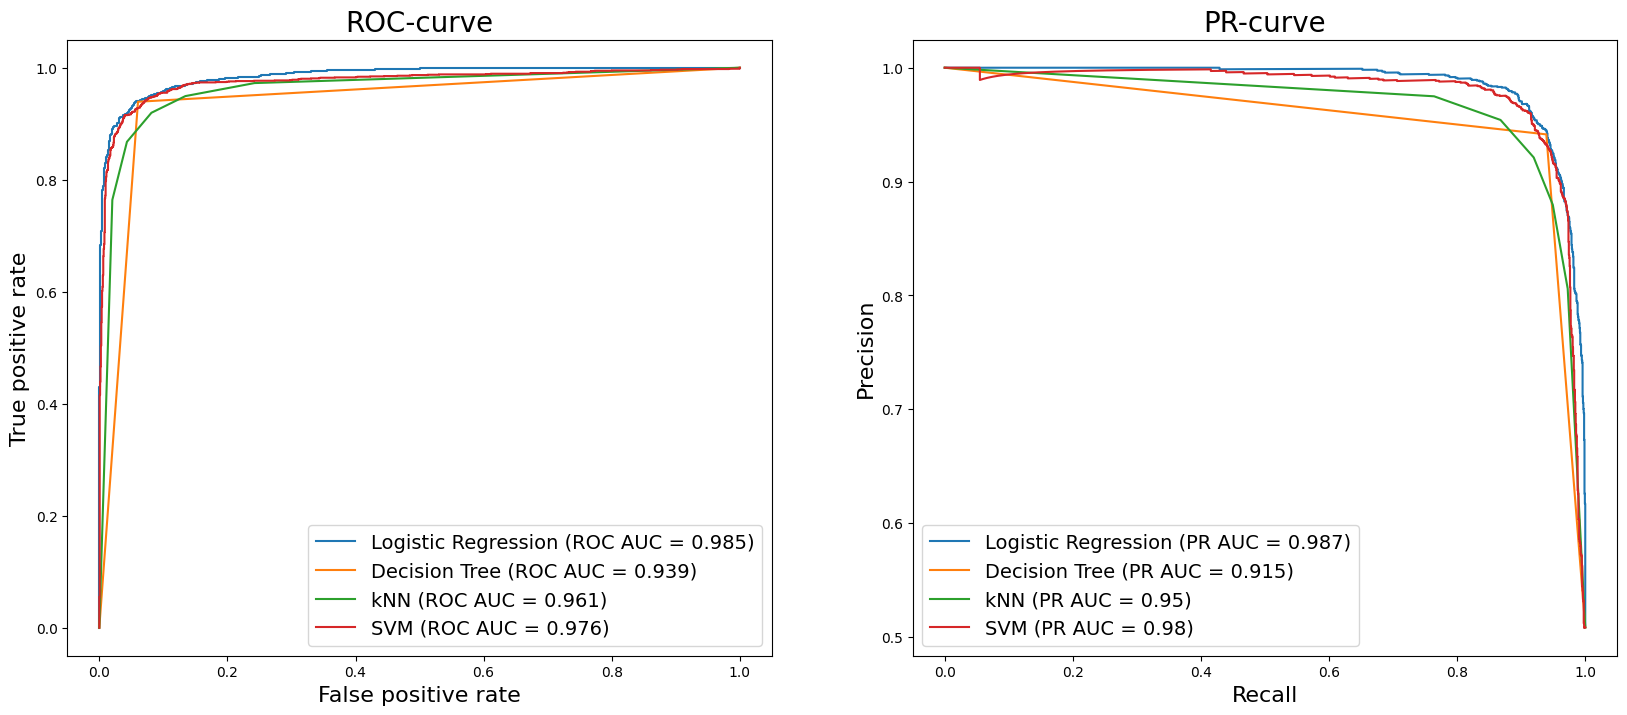

In [45]:
plot_roc_pr_curves(
    y_test,
    {
        "Logistic Regression": proba_logreg,
        "Decision Tree": proba_dt,
        "kNN": proba_knn,
        "SVM": proba_svm,
    }
)

Как упоминалось в теоретической части, можно сравнивать не только площади под ROC- и PR-кривыми, но и сами кривые. Чем выше кривая, тем лучше модель (верно и для ROC-кривой, и для PR-кривой).

Сагрегируем все метрики моделей. 

In [46]:
ans_df = pd.DataFrame(
    [all_metrics_logreg, all_metrics_dt, all_metrics_knn, all_metrics_svm], 
    index=["Logistic Regression", "Decision Tree", "kNN", "SVM"]
)
ans_df

,Accuracy,Precision,Recall,F1_score,ROC AUC,PR AUC,Specificity
Logistic Regression,0.940606,0.945848,0.936830,0.941317,0.985288,0.987089,0.944513
Decision Tree,0.939394,0.941458,0.939213,0.940334,0.939397,0.915139,0.939581
kNN,0.919091,0.921194,0.919547,0.920370,0.961087,0.950413,0.918619
SVM,0.933030,0.939120,0.928486,0.933773,0.975576,0.979582,0.937731


Для каждой метрики выведем список моделей по убыванию их качества. 

In [47]:
for metric in ans_df.columns:
    sorted_ans_df = ans_df.sort_values(by=metric, ascending=False)
    print(
        "{}:{}{}".format(
            metric,
            " " * (20 - len(metric)), 
            sorted_ans_df.index.tolist()
        )
    )

Accuracy:            ['Logistic Regression', 'Decision Tree', 'SVM', 'kNN']
Precision:           ['Logistic Regression', 'Decision Tree', 'SVM', 'kNN']
Recall:              ['Decision Tree', 'Logistic Regression', 'SVM', 'kNN']
F1_score:            ['Logistic Regression', 'Decision Tree', 'SVM', 'kNN']
ROC AUC:             ['Logistic Regression', 'SVM', 'kNN', 'Decision Tree']
PR AUC:              ['Logistic Regression', 'SVM', 'kNN', 'Decision Tree']
Specificity:         ['Logistic Regression', 'Decision Tree', 'SVM', 'kNN']


Согласно всем метрикам наилучшим алгоритмом в данном случае оказалась логистическая регрессия. Хуже всего отработало решающее дерево (судя по ROC AUC и PR AUC) и метод k-ближайших соседей (судя по доли правильных ответов, точности, полноте, F1-мере и специфичности). Однако, посмотрев на численные значения всех метрик всех моделей, можно сказать, что они все обучились достаточно хорошо.  

## Многоклассовая классификация

### Чтение и предобработка данных

In [48]:
from sklearn.datasets import load_wine

In [49]:
wine_data = load_wine()
wine_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [50]:
df = pd.DataFrame(wine_data["data"], columns=wine_data["feature_names"])
target = wine_data["target"]

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [51]:
pd.Series(target).value_counts()

1    71
0    59
2    48
Name: count, dtype: int64

Выборка не идеально сбалансирована, но сильных различий в количестве представителей классов нет. 

В данных представлены только численные признаки, поэтому единственный вариант предобработки данных, который можно сделать на этих данных, — нормализация. Однако мы будем использовать методы, в основе которых лежат деревья, поэтому даже нормализацию проводить не будем. 

In [52]:
# Делим выборку на обучающую и тестовую

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.33, random_state=42)

### Обучение и тестирование моделей

Поскольку существует несколько вариантов агрегации метрик в многоклассовом случае, перепишем функцию `model_train_test`. Новая функция `all_average_multi_class_combinations` обучает и тестирует модель, а также проводит подсчет метрик для различных вариантов агрегации метрик. 

In [53]:
def all_average_multi_class_combinations(X_train, y_train, X_test, y_test, model, verbose=0):
    """После обучения и тестирования модели используются всевозможные аггрегации метрик.

    :param X_train: обучающая выборка
    :param y_train: целевая переменная обучающей выборки
    :param X_test: тестовая выборка
    :param y_test: целевая переменная тестовой выборки
    :param model: классификатор
    :param verbose: если 0, то выводятся только точность, полнота, F1-мера, ROC AUC и PR AUC для различных вариантов аггрегаций, иначе -- все метрики для каждого варианта аггрегации
    :return: точность, полнота, F1-мера, ROC AUC и PR AUC для различных вариантов аггрегаций
    """
    # average="macro" и multi_class="ovr" -> ROC AUC чувствителен к несбалансированности классов 
    # average="macro" и multi_class="ovo" -> ROC AUC не чувствителен к несбалансированности классов 

    model.fit(X_train, y_train) # обучение модели
    pred = model.predict(X_test) # получение предсказаний (классов)
    proba = model.predict_proba(X_test) # получение предсказаний (вероятности принадлежности к каждому классу)

    if verbose > 0:
        print(str(model), end="\n\n")

    ans = dict()
    ans["ROC AUC"] = dict()
    metrics_to_compare = ["Precision", "Recall", "F1_score", "PR AUC"]
    for m in metrics_to_compare:
        ans[m] = dict() 

    for average in ["macro", "micro", "weighted"]:
        for multi_class in ["ovr", "ovo"]:
            if verbose > 0:
                print("\n{}_{}".format(average, multi_class))
            
            # вычисление всех метрик
            all_metrics = get_all_metrics(
                y_test, 
                pred, 
                proba, 
                calc_specificity=False,
                print_metrics=verbose > 0,
                average=average,
                multi_class=multi_class,
            )

            for m in metrics_to_compare:
                ans[m][average] = all_metrics[m]
            ans["ROC AUC"][multi_class] = all_metrics["ROC AUC"]
    if verbose > 0:
        print("-"*100, end="\n\n")
    for k, v in ans.items():
        print(k, "\n", v)
    return ans

### Сравненмие моделей

В данной задаче будем сравнивать решающее дерево с одним из вариантов ансамблей решающих деревьев — случайным лесом. 

In [58]:
dt = all_average_multi_class_combinations(
    X_train, y_train, 
    X_test, y_test, 
    DecisionTreeClassifier(),
    verbose=1, 
)
if isinstance(dt, dict):
    dt_df = pd.DataFrame([dt]).T
    dt_df.columns = ['Значение']
    print(dt_df)
    
# Если нужно добавить RMSE вручную
from sklearn.metrics import mean_squared_error
import numpy as np

# Предполагая, что у нас есть предсказания
y_pred = dt['predictions'] if 'predictions' in dt else None
if y_pred is not None:
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Создаем полную таблицу метрик
    metrics_df = pd.DataFrame({
        'Метрика': ['RMSE', 'Точность', 'Precision', 'Recall', 'F1-Score'],
        'Значение': [
            rmse,
            dt.get('accuracy', 'N/A'),
            dt.get('precision', 'N/A'),
            dt.get('recall', 'N/A'),
            dt.get('f1', 'N/A')
        ]
    })
    print("\n" + "="*50)
    print("Метрики качества модели Decision Tree")
    print("="*50)
    print(metrics_df.to_string(index=False))

DecisionTreeClassifier()


macro_ovr
Accuracy = 0.9491525423728814
Precision = 0.9568151147098516
Recall = 0.9444444444444443
F1_score = 0.9495313881520778
ROC AUC = 0.9584249084249085
PR AUC = 0.9199630976615811
Specificity = 0.9724053724053724

macro_ovo
Accuracy = 0.9491525423728814
Precision = 0.9568151147098516
Recall = 0.9444444444444443
F1_score = 0.9495313881520778
ROC AUC = 0.9583333333333334
PR AUC = 0.9199630976615811
Specificity = 0.9724053724053724

micro_ovr
Accuracy = 0.9491525423728814
Precision = 0.9491525423728814
Recall = 0.9491525423728814
F1_score = 0.9491525423728814
ROC AUC = 0.9584249084249085
PR AUC = 0.9178397012352772
Specificity = 0.9724053724053724

micro_ovo
Accuracy = 0.9491525423728814
Precision = 0.9491525423728814
Recall = 0.9491525423728814
F1_score = 0.9491525423728814
ROC AUC = 0.9583333333333334
PR AUC = 0.9178397012352772
Specificity = 0.9724053724053724

weighted_ovr
Accuracy = 0.9491525423728814
Precision = 0.9508680436423522
Recall = 0.94915254

Как видно из получившихся результатов, агрегация в данном случае не сильно повлияла на итоговое значение каждой из метрик. 

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
rf = all_average_multi_class_combinations(
    X_train, y_train, 
    X_test, y_test, 
    RandomForestClassifier(),
    verbose=1, 
)

RandomForestClassifier()


macro_ovr
Accuracy = 1.0
Precision = 1.0
Recall = 1.0
F1_score = 1.0
ROC AUC = 1.0
PR AUC = 1.0
Specificity = 1.0

macro_ovo
Accuracy = 1.0
Precision = 1.0
Recall = 1.0
F1_score = 1.0
ROC AUC = 1.0
PR AUC = 1.0
Specificity = 1.0

micro_ovr
Accuracy = 1.0
Precision = 1.0
Recall = 1.0
F1_score = 1.0
ROC AUC = 1.0
PR AUC = 1.0
Specificity = 1.0

micro_ovo
Accuracy = 1.0
Precision = 1.0
Recall = 1.0
F1_score = 1.0
ROC AUC = 1.0
PR AUC = 1.0
Specificity = 1.0

weighted_ovr
Accuracy = 1.0
Precision = 1.0
Recall = 1.0
F1_score = 1.0
ROC AUC = 1.0
PR AUC = 1.0
Specificity = 1.0

weighted_ovo
Accuracy = 1.0
Precision = 1.0
Recall = 1.0
F1_score = 1.0
ROC AUC = 1.0
PR AUC = 1.0
Specificity = 1.0
----------------------------------------------------------------------------------------------------

ROC AUC 
 {'ovr': np.float64(1.0), 'ovo': np.float64(1.0)}
Precision 
 {'macro': 1.0, 'micro': 1.0, 'weighted': 1.0}
Recall 
 {'macro': 1.0, 'micro': 1.0, 'weighted': 1.0}
F1_s

Случайный лес выдает почти идеальные предсказания, поэтому разница в агрегации результатов небольшая. Можем визуализировать каждое из деревьев, чтобы посмотреть, как достигаются почти идеальные предсказания. 

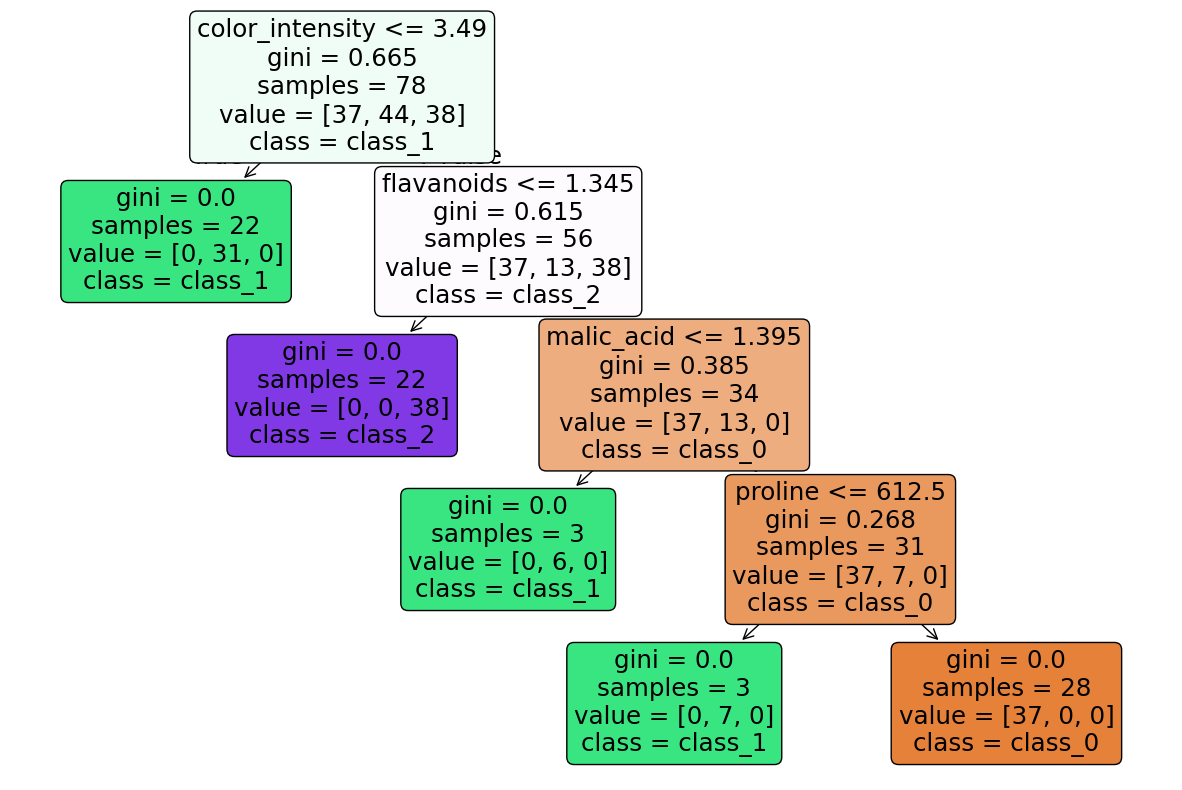

In [57]:
from sklearn.tree import plot_tree

rf_clf = RandomForestClassifier() 
rf_clf.fit(X_train, y_train)

fig = plt.figure(figsize=(15, 10))
plot_tree(
    rf_clf.estimators_[0], # визуализация дерева с индексом 0; всего len(rf_clf.estimators_) деревьев
    feature_names=wine_data.feature_names,
    class_names=wine_data.target_names,
    filled=True, 
    impurity=True, 
    rounded=True
);

Таким образом, для каждой задачи, исходя из ее особенностей, нужно выбирать модель и метрику качества. При выборе метрики качества лучше исходить из того, сбалансированная ли выборка.  

**Сбалансированная выборка:** 
* *Точность/доля правильных ответов (accuracy)*. При этом легко интерпретируемая метрика
* *ROC AUC*. Использует вероятности принадлежности к классам, которые не обязательно должны быть хорошо откалиброваны. Теоретически может работать и с неидеально сбалансированной выборкой, но при сильном дисбалансе классов становится нерепрезентативной

**Несбалансированная выборка:**   
* *Точность (precision), полнота (recall), специфичность (specificity, TNR)*. Стоит учитывать, что обычно нужны не каждая из них по отдельности, а их баланс
* *F1-мера*. Является одним числом, среднее гармоническое точности и полноты
* *PR AUC*. Также является одним числом, но, кроме этого, может помочь выбрать порог классификатора